In [1]:
import numpy as np

In [2]:
class perceptron:
    def __init__(self, eta = 0.01, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        seed = np.random.RandomState(self.random_state)
        self.w = seed.normal(loc = 0.0, scale = 1.0, size = X.shape[1])
        self.b = np.float64(0)
        self.error = []

        for iter in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w += update * xi
                self.b += update
                errors += int(update != 0.0)
            self.error.append(errors)

        return self
    
    def net_input(self, X):
        return np.dot(X, self.w) + self.b
    
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

In [3]:
import os
import pandas as pd

s = 'https://archive.ics.uci.edu/ml/'\
    'machine-learning-databases/iris/iris.data'

print(s)

https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


In [4]:
df = pd.read_csv(s, header = None, encoding = 'utf-8')

In [5]:
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [6]:
import matplotlib.pyplot as plt

y = df.iloc[0:100, 4] # 행 0 ~ 99, 5번째 column
y = np.where(y == "Iris-setosa", 0, 1) # setosa -> 0, versicolor -> 1
X = df.iloc[0:100, [0, 2]].values

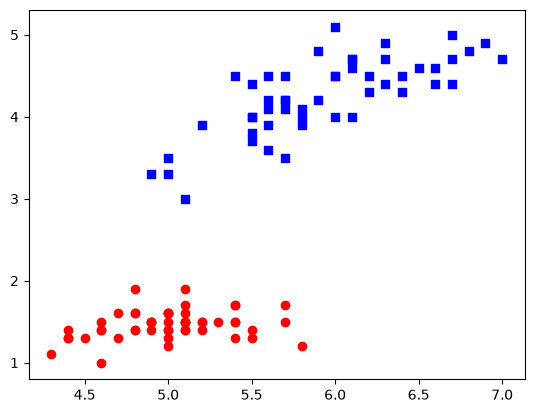

In [7]:
plt.scatter(X[:50, 0], X[:50, 1],
            color = 'red', marker = 'o', label = 'Setosa')

plt.scatter(X[50:100, 0], X[50:100, 1],
            color = "blue", marker = 's', label = 'Versicolor')

plt.show()

In [8]:
ppn = perceptron(eta = 0.1, n_iter = 10)
ppn.fit(X, y)

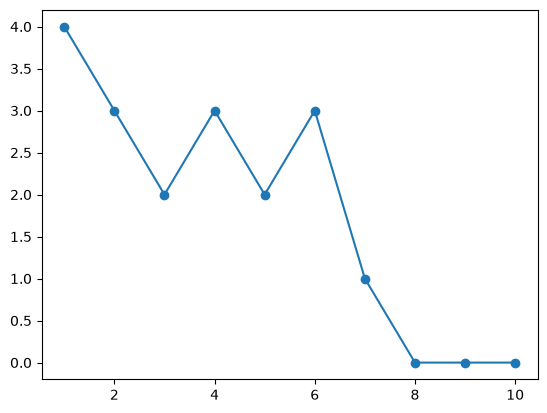

In [9]:
plt.plot(range(1, len(ppn.error) + 1),
         ppn.error, marker = 'o')

In [10]:
from matplotlib.colors import ListedColormap
def plot_decision_regions(X, y, classifier, resolution = 0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[:len(np.unique(y))]) # L("red", "blue")

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution)) # 격자점
    
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha = 0.3, cmap = cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = X[y == cl, 0],
                    y = X[y == cl, 1])
        

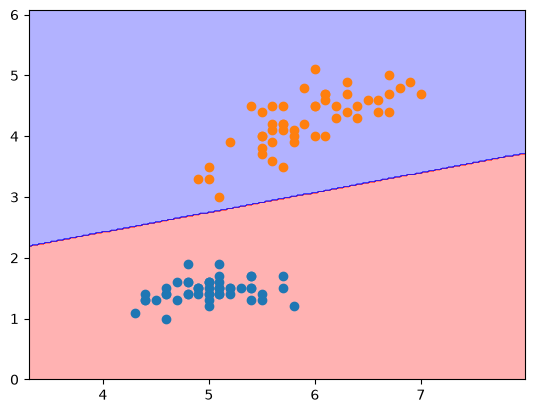

In [11]:
plot_decision_regions(X, y, classifier = ppn)